<a href="https://colab.research.google.com/github/kakimovaazhar-coder/helmet_syst/blob/main/helmet_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q "ultralytics>=8.0,<9.0" kaggle scikit-learn pandas matplotlib seaborn opencv-python pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
SAVE_DIR = Path('/content/drive/MyDrive/Helmet_YOLOv8_results')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(SAVE_DIR)

Mounted at /content/drive
/content/drive/MyDrive/Helmet_YOLOv8_results


In [ ]:
from google.colab import files
import os, shutil

if not Path('/root/.kaggle/kaggle.json').exists():
    uploaded = files.upload()
    assert 'kaggle.json' in uploaded, 'Нужно загрузить kaggle.json'
    Path('/root/.kaggle').mkdir(parents=True, exist_ok=True)
    shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle API ready')

Saving kaggle.json to kaggle.json
Kaggle API ready


In [ ]:
DATA_ROOT = Path('/content/datasets/hard_hat_raw')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not (DATA_ROOT / 'images').exists():
    !kaggle datasets download -d andrewmvd/hard-hat-detection -p /content/datasets
    !unzip -q /content/datasets/hard-hat-detection.zip -d /content/datasets/hard_hat_raw
    !rm /content/datasets/hard-hat-detection.zip

print('Raw dataset folders:')
!find /content/datasets/hard_hat_raw -maxdepth 2 -type d | sort

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [00:09<00:00, 134MB/s]

Raw dataset folders:
/content/datasets/hard_hat_raw
/content/datasets/hard_hat_raw/annotations
/content/datasets/hard_hat_raw/images


In [ ]:
import xml.etree.ElementTree as ET
from collections import Counter
import pandas as pd

CLASSES = ['helmet', 'head']
CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}

RAW_IMAGES = DATA_ROOT / 'images'
RAW_ANN = DATA_ROOT / 'annotations'
YOLO_ROOT = Path('/content/datasets/helmet_head_yolov8')
ALL_IMAGES = YOLO_ROOT / 'all' / 'images'
ALL_LABELS = YOLO_ROOT / 'all' / 'labels'
ALL_IMAGES.mkdir(parents=True, exist_ok=True)
ALL_LABELS.mkdir(parents=True, exist_ok=True)

def voc_box_to_yolo(width, height, xmin, ymin, xmax, ymax):
    xmin = max(0, min(width - 1, xmin))
    xmax = max(0, min(width - 1, xmax))
    ymin = max(0, min(height - 1, ymin))
    ymax = max(0, min(height - 1, ymax))
    box_w = max(1, xmax - xmin)
    box_h = max(1, ymax - ymin)
    x_center = xmin + box_w / 2
    y_center = ymin + box_h / 2
    return x_center / width, y_center / height, box_w / width, box_h / height

rows = []
image_count = 0
object_counter = Counter()

for xml_path in sorted(RAW_ANN.glob('*.xml')):
    root = ET.parse(xml_path).getroot()
    filename = root.findtext('filename')
    size = root.find('size')
    width = int(size.findtext('width'))
    height = int(size.findtext('height'))
    image_path = RAW_IMAGES / filename
    if not image_path.exists():
        continue

    label_lines = []
    for obj in root.findall('object'):
        name = obj.findtext('name')
        if name not in CLASS_TO_ID:
            continue
        bnd = obj.find('bndbox')
        xmin = int(float(bnd.findtext('xmin')))
        ymin = int(float(bnd.findtext('ymin')))
        xmax = int(float(bnd.findtext('xmax')))
        ymax = int(float(bnd.findtext('ymax')))
        x, y, w, h = voc_box_to_yolo(width, height, xmin, ymin, xmax, ymax)
        class_id = CLASS_TO_ID[name]
        label_lines.append(f'{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}')
        object_counter[name] += 1
        rows.append({'image': filename, 'class': name, 'class_id': class_id})

    if label_lines:
        shutil.copy2(image_path, ALL_IMAGES / filename)
        (ALL_LABELS / f'{Path(filename).stem}.txt').write_text('\n'.join(label_lines) + '\n')
        image_count += 1

print('Images with helmet/head labels:', image_count)
print('Objects:', dict(object_counter))
labels_df = pd.DataFrame(rows)
labels_df.head()

Images with helmet/head labels: 5000
Objects: {'helmet': 18966, 'head': 5785}


,image,class,class_id
0,hard_hat_workers0.png,helmet,0
1,hard_hat_workers0.png,helmet,0
2,hard_hat_workers0.png,helmet,0
3,hard_hat_workers0.png,helmet,0
4,hard_hat_workers0.png,helmet,0


In [ ]:
from sklearn.model_selection import train_test_split

all_images = sorted(ALL_IMAGES.glob('*'))
train_imgs, temp_imgs = train_test_split(all_images, test_size=0.30, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.33, random_state=42)

splits = {'train': train_imgs, 'val': val_imgs, 'test': test_imgs}

for split, image_paths in splits.items():
    img_dir = YOLO_ROOT / 'images' / split
    lab_dir = YOLO_ROOT / 'labels' / split
    shutil.rmtree(img_dir, ignore_errors=True)
    shutil.rmtree(lab_dir, ignore_errors=True)
    img_dir.mkdir(parents=True, exist_ok=True)
    lab_dir.mkdir(parents=True, exist_ok=True)
    for img in image_paths:
        shutil.copy2(img, img_dir / img.name)
        label = ALL_LABELS / f'{img.stem}.txt'
        shutil.copy2(label, lab_dir / label.name)
    print(split, len(image_paths))

train 3500
val 1005
test 495


In [ ]:
import yaml

data_yaml = {
    'path': str(YOLO_ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(CLASSES),
    'names': CLASSES,
}

DATA_YAML = YOLO_ROOT / 'data.yaml'
DATA_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False))
print(DATA_YAML.read_text())

path: /content/datasets/helmet_head_yolov8
train: images/train
val: images/val
test: images/test
nc: 2
names:
- helmet
- head



In [ ]:
def count_split(split):
    counter = Counter()
    for label_file in (YOLO_ROOT / 'labels' / split).glob('*.txt'):
        for line in label_file.read_text().splitlines():
            if line.strip():
                class_id = int(float(line.split()[0]))
                counter[CLASSES[class_id]] += 1
    return counter

count_rows = []
for split in ['train', 'val', 'test']:
    counts = count_split(split)
    for cls in CLASSES:
        count_rows.append({'split': split, 'class': cls, 'objects': counts.get(cls, 0)})

class_counts = pd.DataFrame(count_rows)
class_counts

,split,class,objects
0,train,helmet,13502
1,train,head,3929
2,val,helmet,3634
3,val,head,1218
4,test,helmet,1830
5,test,head,638


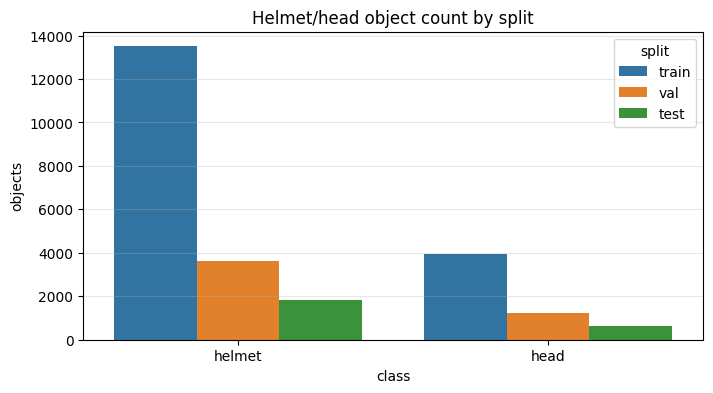

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(data=class_counts, x='class', y='objects', hue='split')
plt.title('Helmet/head object count by split')
plt.grid(axis='y', alpha=0.3)
plt.show()

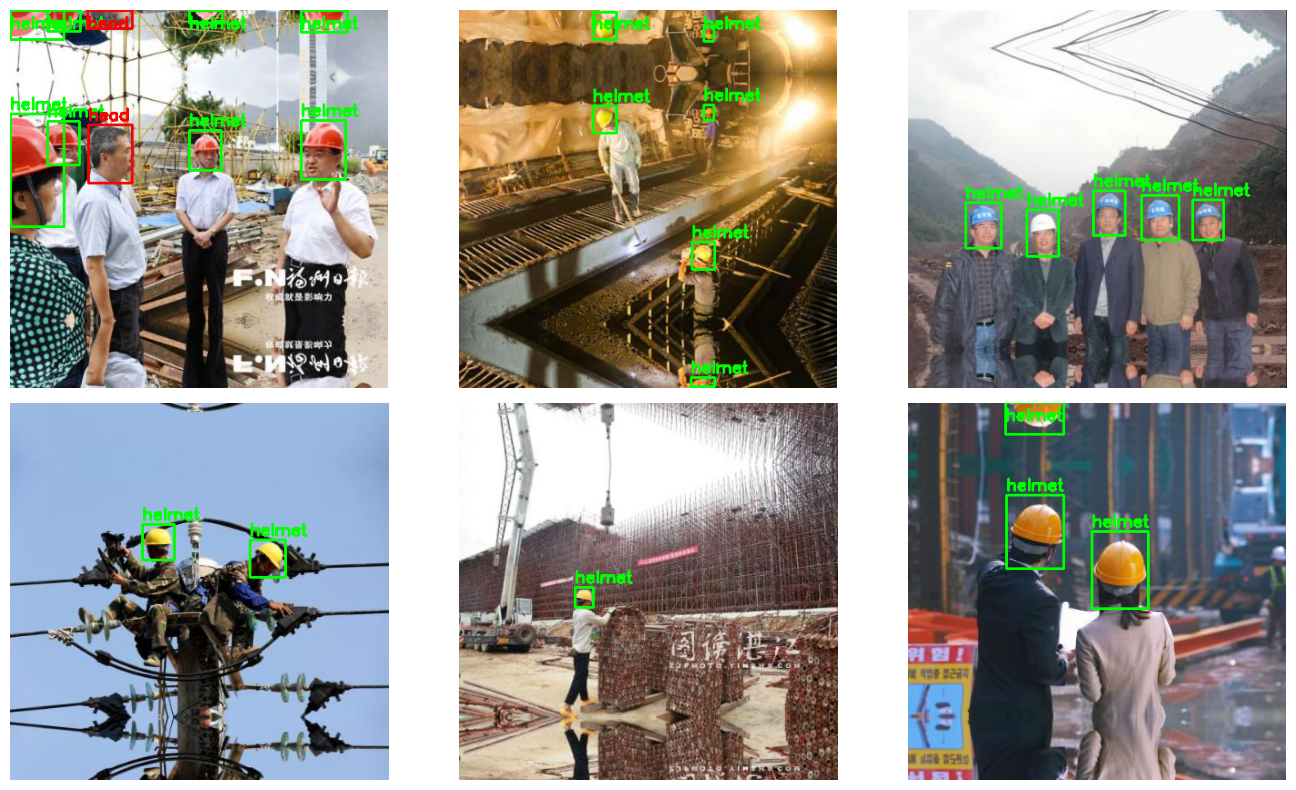

In [ ]:
import cv2
import random
from IPython.display import display

def draw_label_sample(image_path):
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    label_path = YOLO_ROOT / 'labels' / 'train' / f'{image_path.stem}.txt'
    for line in label_path.read_text().splitlines():
        cls, x, y, bw, bh = map(float, line.split())
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        cls = int(cls)
        color = (0, 255, 0) if cls == 0 else (0, 0, 255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASSES[cls], (x1, max(20, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

sample_images = random.sample(list((YOLO_ROOT / 'images' / 'train').glob('*')), 6)
plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_images, 1):
    plt.subplot(2, 3, i)
    plt.imshow(draw_label_sample(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()

## 10. Обучение YOLOv8n

Это основной прогон. Не 10 эпох, как было раньше, а 100 с early stopping. Если качество будет хорошее, берём `best.pt`. Если нет — будем чистить данные или пробовать `yolov8s.pt`.

In [ ]:
from ultralytics import YOLO

RUN_NAME = 'helmet_head_yolov8n_v1'
model = YOLO('yolov8n.pt')

train_results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=25,
    project=str(SAVE_DIR),
    name=RUN_NAME,
    exist_ok=True,
    pretrained=True,
    optimizer='auto',
    cos_lr=True,
    close_mosaic=10,
    plots=True,
    seed=42,
    deterministic=True,
    workers=2,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/helmet_head_yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0

In [ ]:
RUN_DIR = SAVE_DIR / RUN_NAME
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
LAST_PT = RUN_DIR / 'weights' / 'last.pt'

print('RUN_DIR:', RUN_DIR)
print('BEST_PT:', BEST_PT, BEST_PT.exists())
print('LAST_PT:', LAST_PT, LAST_PT.exists())

RUN_DIR: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1
BEST_PT: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/weights/best.pt True
LAST_PT: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/weights/last.pt True


In [ ]:
best_model = YOLO(str(BEST_PT))

val_metrics = best_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=640,
    conf=0.001,
    iou=0.6,
    plots=True,
    save_json=True,
    project=str(SAVE_DIR),
    name=RUN_NAME + '_val',
    exist_ok=True,
)

print('Precision:', val_metrics.box.mp)
print('Recall:', val_metrics.box.mr)
print('mAP50:', val_metrics.box.map50)
print('mAP50-95:', val_metrics.box.map)
print('mAP75:', val_metrics.box.map75)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3662.3±962.8 MB/s, size: 283.7 KB)
val: Scanning /content/datasets/helmet_head_yolov8/labels/val.cache... 1005 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1005/1005 324.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 3.8it/s 16.6s
                   all       1005       4852      0.941      0.889       0.95      0.624
                helmet        904       3634      0.954      0.914      0.966      0.642
                  head        196       1218      0.929      0.865      0.933      0.607
Speed: 2.2ms preprocess, 4.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Saving /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1_val/predictions.json...
Results saved to /cont

In [ ]:
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    conf=0.001,
    iou=0.6,
    plots=True,
    save_json=True,
    project=str(SAVE_DIR),
    name=RUN_NAME + '_test',
    exist_ok=True,
)

summary = pd.DataFrame([
    {'split': 'val', 'precision': val_metrics.box.mp, 'recall': val_metrics.box.mr, 'mAP50': val_metrics.box.map50, 'mAP50-95': val_metrics.box.map},
    {'split': 'test', 'precision': test_metrics.box.mp, 'recall': test_metrics.box.mr, 'mAP50': test_metrics.box.map50, 'mAP50-95': test_metrics.box.map},
])
summary.to_csv(RUN_DIR / 'diploma_val_test_summary.csv', index=False)
summary

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1602.8±166.0 MB/s, size: 220.4 KB)
val: Scanning /content/datasets/helmet_head_yolov8/labels/test... 495 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 495/495 1.2Kit/s 0.4s
val: New cache created: /content/datasets/helmet_head_yolov8/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 2.7it/s 11.3s
                   all        495       2468      0.912      0.881       0.93       0.61
                helmet        452       1830      0.948      0.894      0.959      0.618
                  head         90        638      0.876      0.868      0.902      0.601
Speed: 4.0ms preprocess, 4.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Saving /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1_test/predictions.json...
Results saved to /content/drive/

,split,precision,recall,mAP50,mAP50-95
0,val,0.941233,0.889473,0.949501,0.624218
1,test,0.912082,0.881212,0.930492,0.609699



results.png


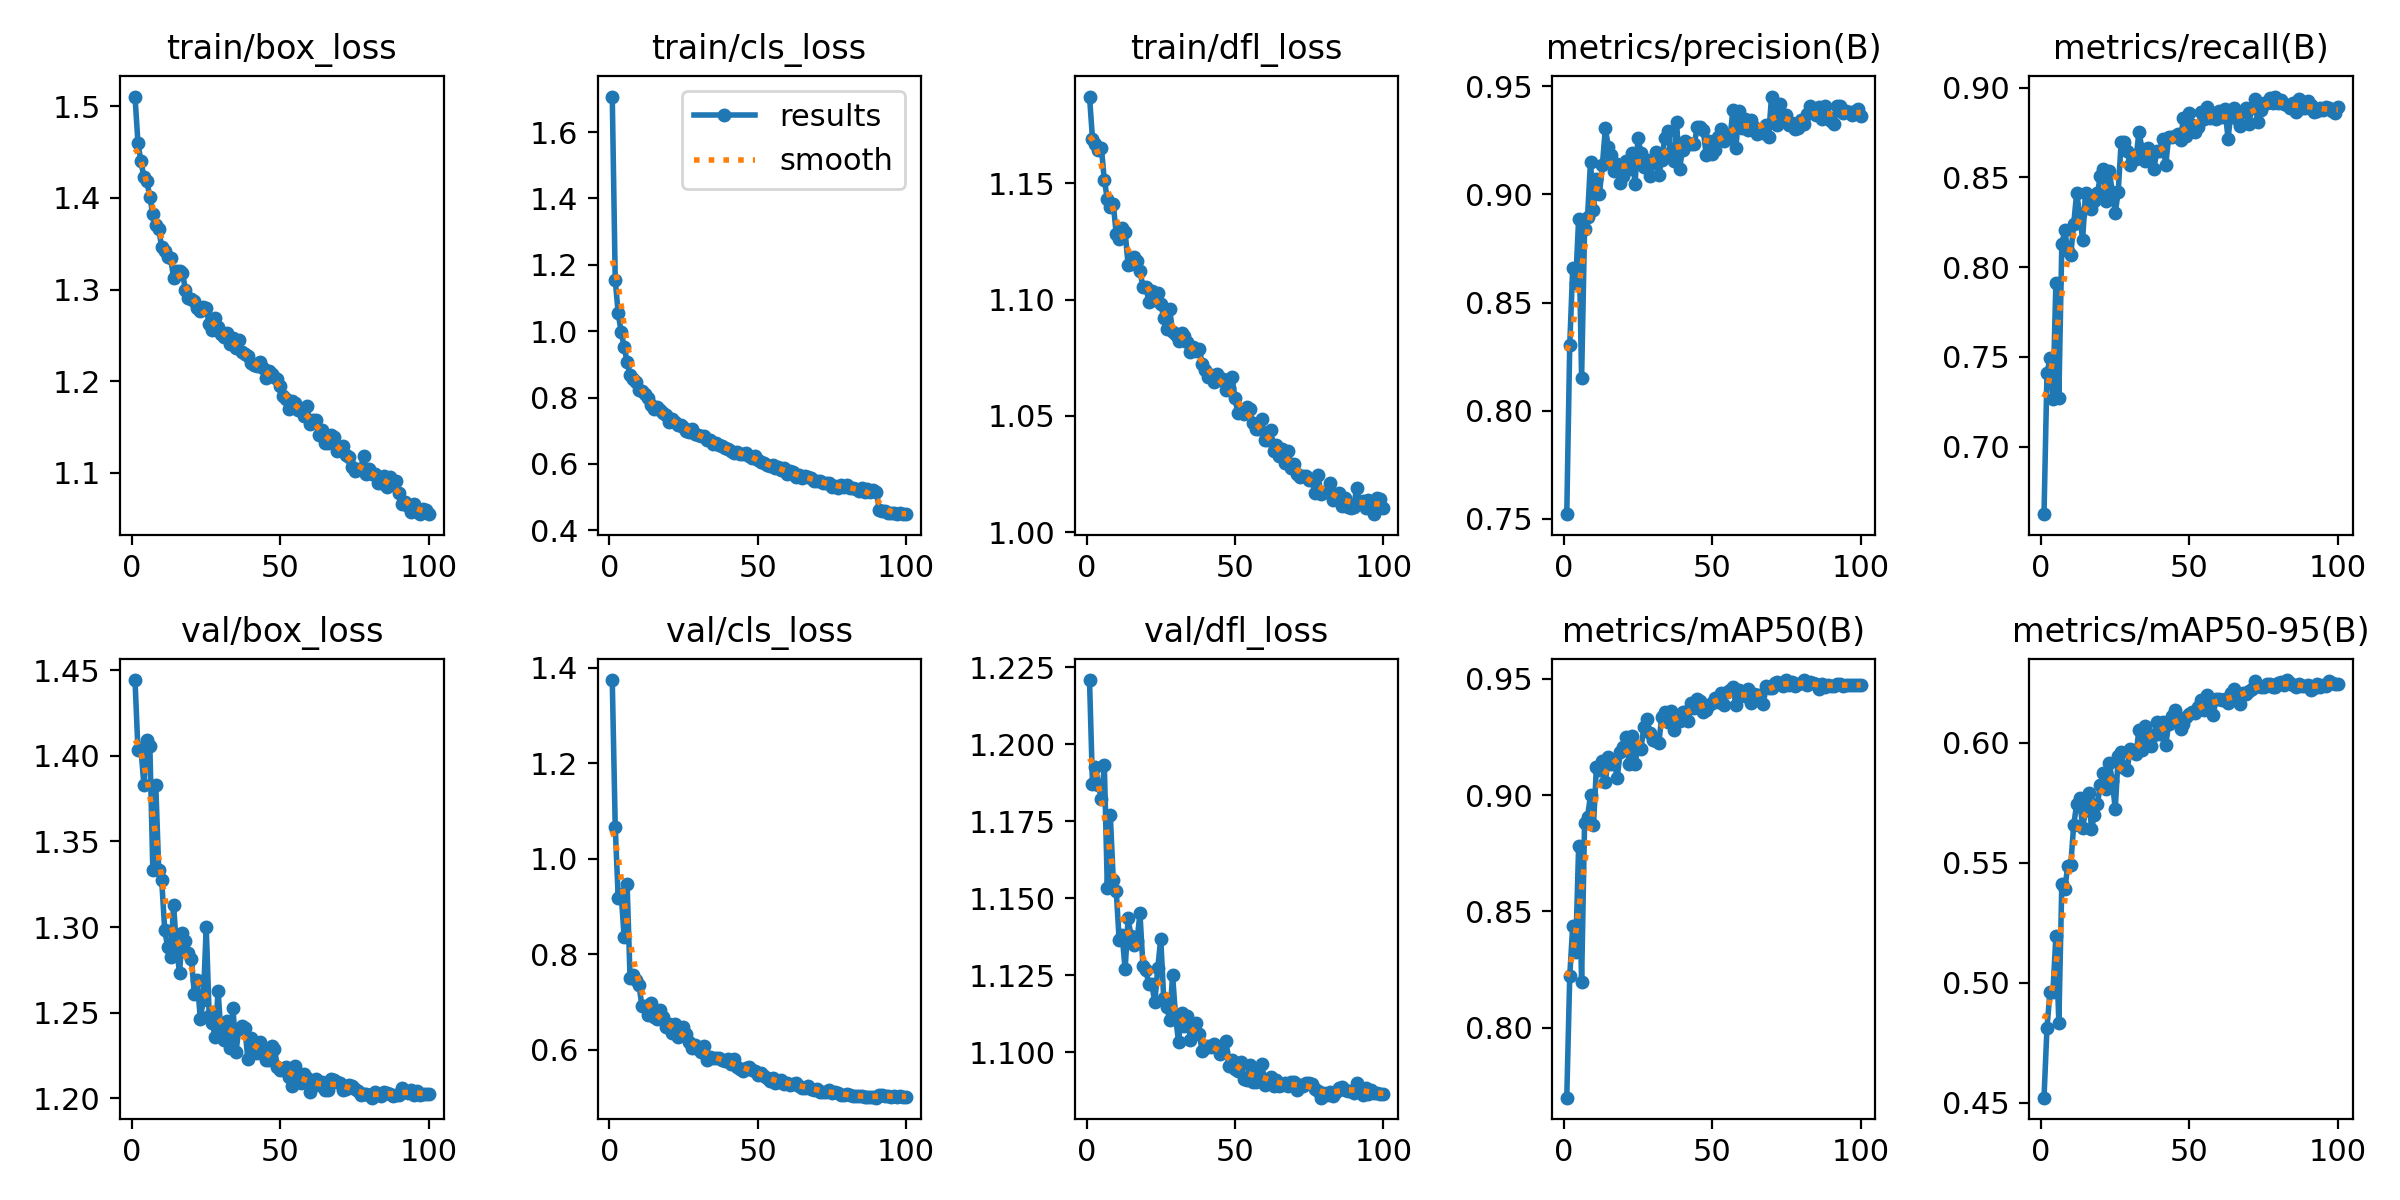


confusion_matrix.png


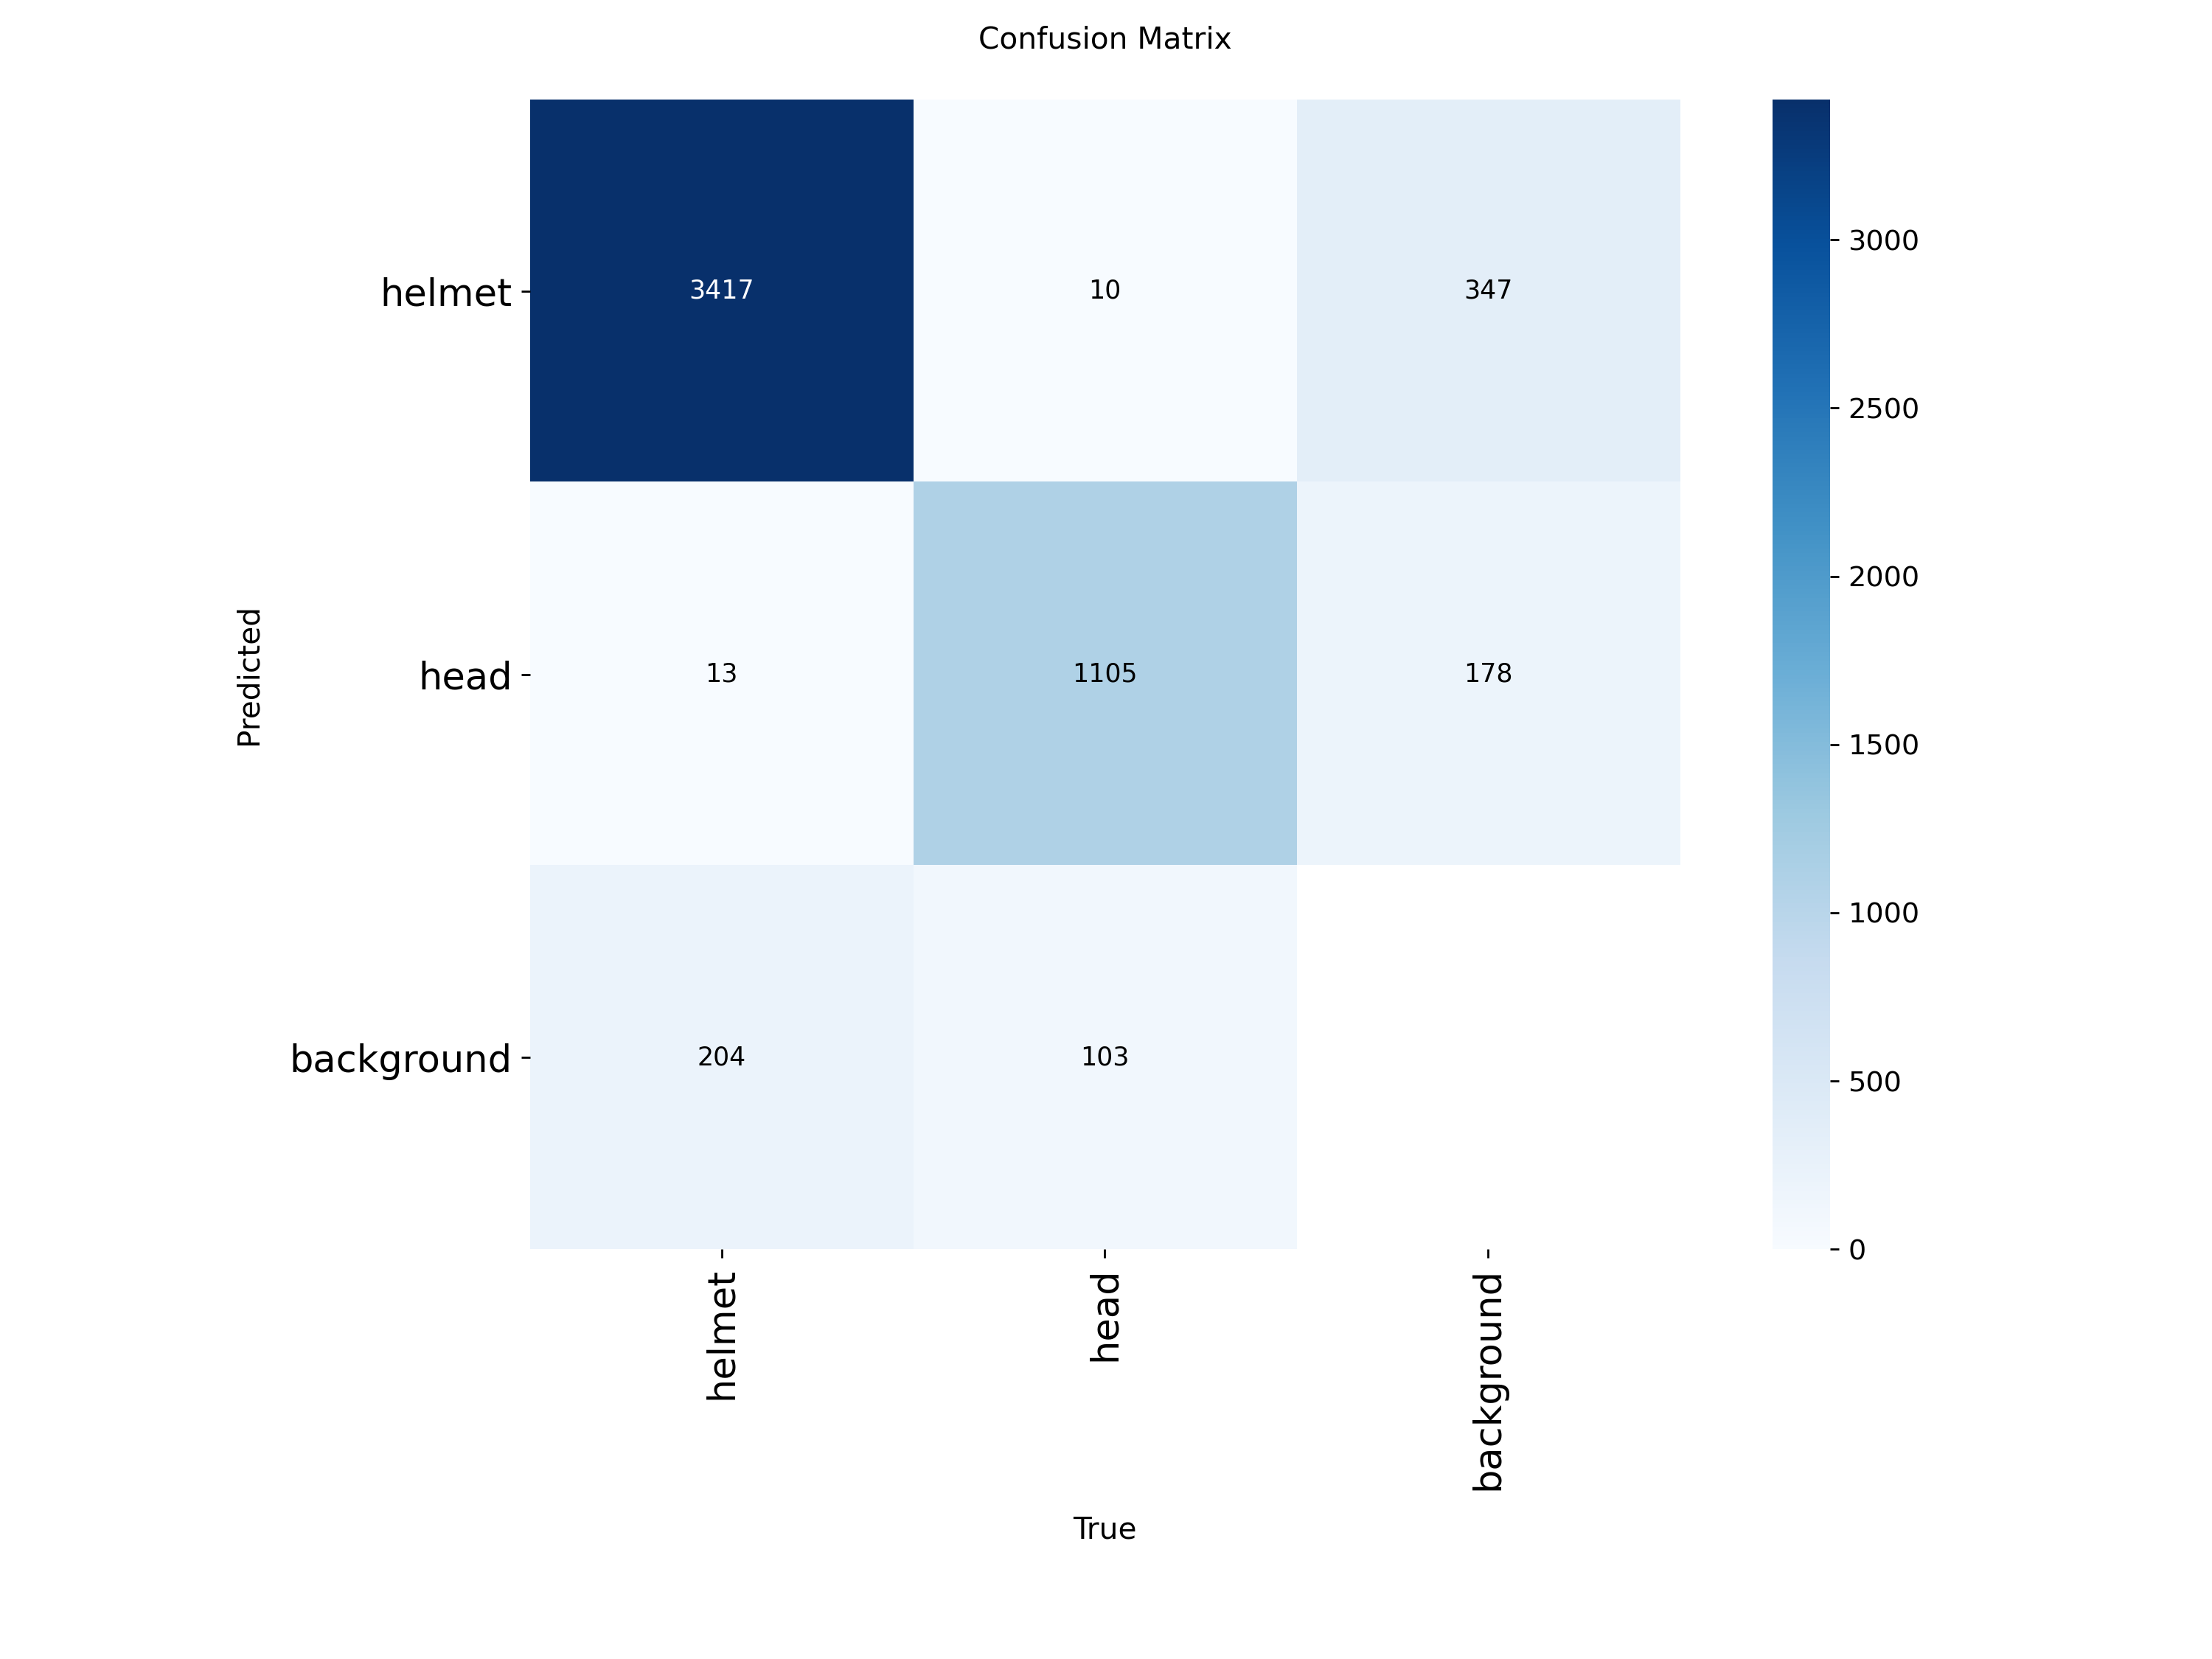


confusion_matrix_normalized.png


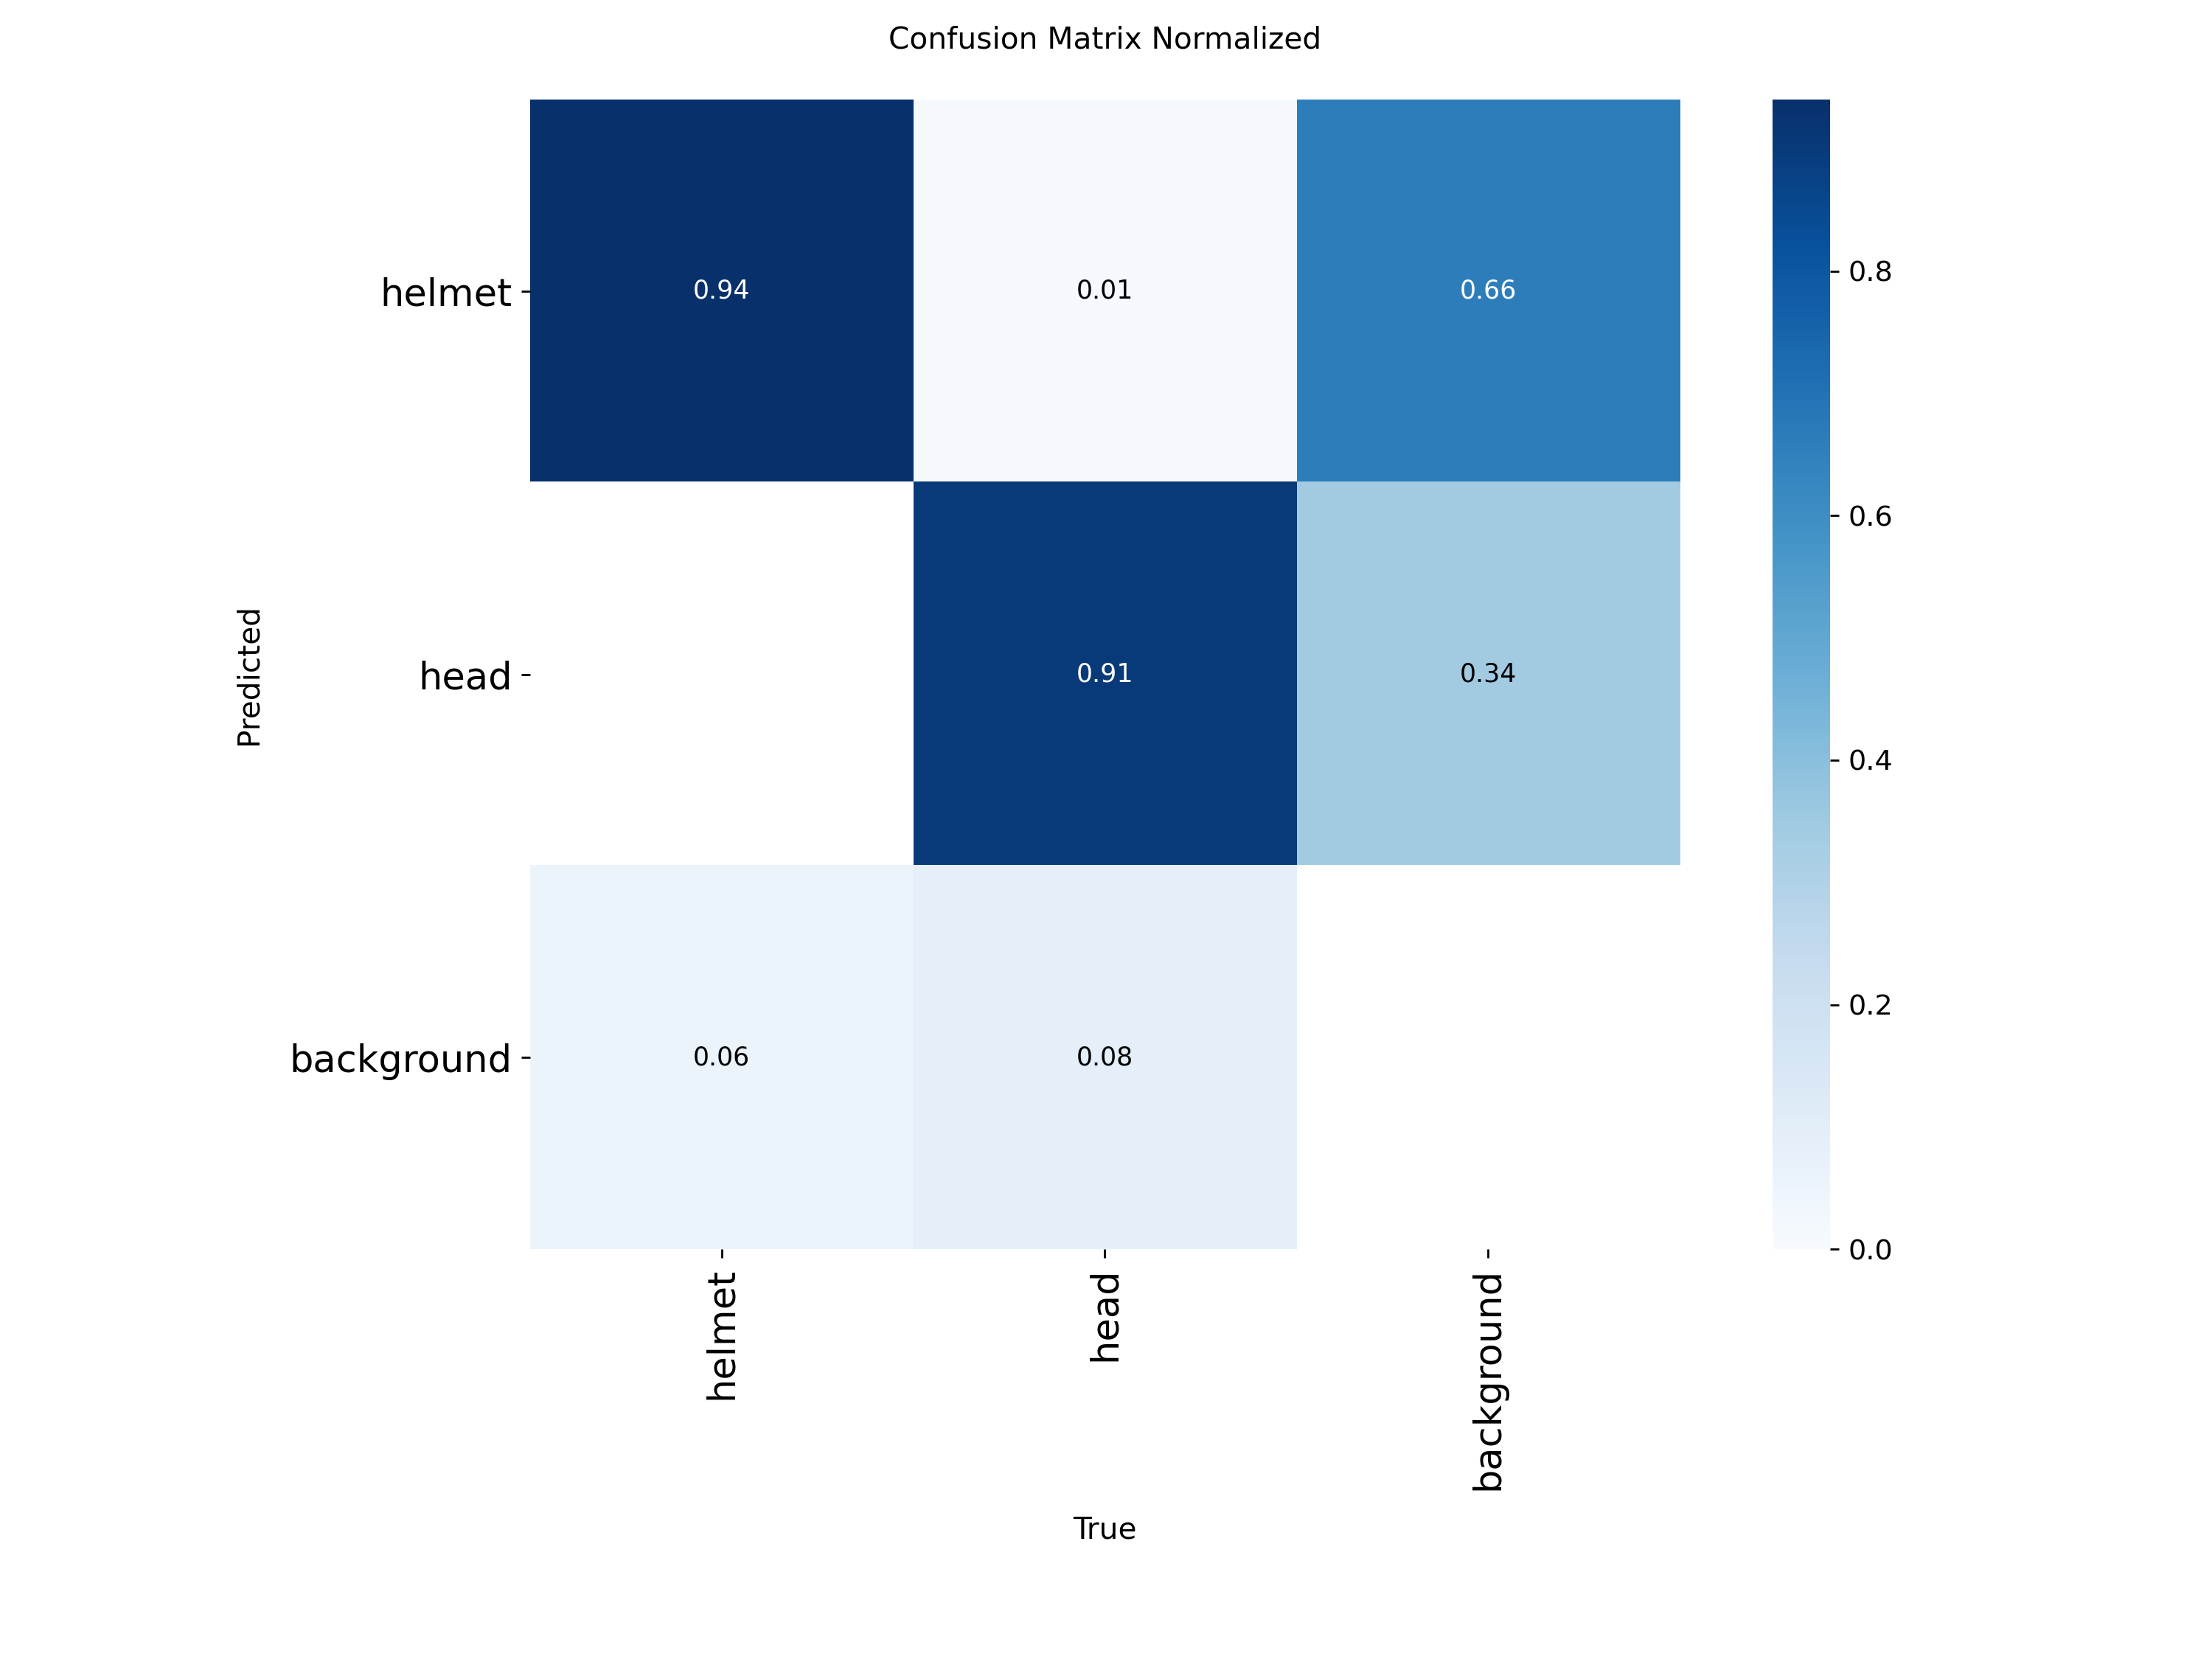

missing: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/PR_curve.png
missing: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/F1_curve.png
missing: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/P_curve.png
missing: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/R_curve.png


In [ ]:
from IPython.display import Image, display

plot_names = [
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'PR_curve.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
]

for name in plot_names:
    path = RUN_DIR / name
    if path.exists():
        print('\n' + name)
        display(Image(filename=str(path), width=900))
    else:
        print('missing:', path)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,8748.86,1.05750,0.45121,1.01166,0.93795,0.88953,0.94720,0.62375,1.20448,0.50313,1.08762,0.000027,0.000027,0.000027
96,97,8834.65,1.05502,0.44875,1.00775,0.93654,0.88876,0.94711,0.62589,1.20198,0.50178,1.08667,0.000023,0.000023,0.000023
97,98,8921.72,1.06032,0.45086,1.01489,0.93854,0.88687,0.94729,0.62503,1.20271,0.50253,1.08665,0.000020,0.000020,0.000020
98,99,9008.54,1.05966,0.44863,1.01406,0.93949,0.88591,0.94717,0.62474,1.20228,0.50178,1.08654,0.000018,0.000018,0.000018
99,100,9094.18,1.05486,0.44854,1.01053,0.93627,0.88903,0.94740,0.62477,1.20239,0.50201,1.08629,0.000017,0.000017,0.000017


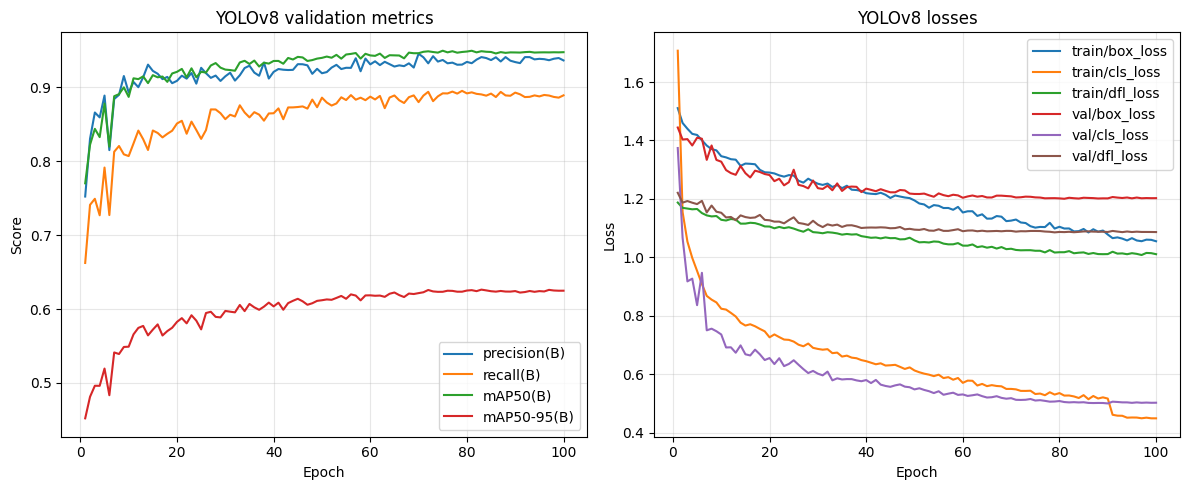

In [ ]:
history = pd.read_csv(RUN_DIR / 'results.csv')
history.columns = [c.strip() for c in history.columns]
display(history.tail())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for col in ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
    if col in history.columns:
        plt.plot(history['epoch'], history[col], label=col.replace('metrics/', ''))
plt.title('YOLOv8 validation metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
for col in ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']:
    if col in history.columns:
        plt.plot(history['epoch'], history[col], label=col)
plt.title('YOLOv8 losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(RUN_DIR / 'diploma_training_summary.png', dpi=200)
plt.show()

history.to_csv(RUN_DIR / 'training_metrics_clean.csv', index=False)

In [ ]:
pred_results = best_model.predict(
    source=str(YOLO_ROOT / 'images' / 'test'),
    imgsz=640,
    conf=0.25,
    save=True,
    project=str(SAVE_DIR),
    name=RUN_NAME + '_test_predictions',
    exist_ok=True,
)

PRED_DIR = SAVE_DIR / (RUN_NAME + '_test_predictions')
print(PRED_DIR)


image 1/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1004.png: 640x640 7 helmets, 7.2ms
image 2/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers101.png: 640x640 8 heads, 7.2ms
image 3/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1012.png: 640x640 5 helmets, 7.2ms
image 4/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1036.png: 640x640 3 helmets, 7.2ms
image 5/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1056.png: 640x640 3 helmets, 7.2ms
image 6/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1059.png: 640x640 5 heads, 7.2ms
image 7/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1069.png: 640x640 7 helmets, 7.2ms
image 8/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1079.png: 640x640 14 helmets, 3 heads, 8.8ms
image 9/495 /content/datasets/helmet_head_yolov8/images/test/hard_hat_workers1096.png: 640x640 2 h

In [ ]:
rpi_metrics = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=320,
    conf=0.001,
    iou=0.6,
    plots=True,
    project=str(SAVE_DIR),
    name=RUN_NAME + '_test_imgsz320',
    exist_ok=True,
)

print('Raspberry imgsz=320')
print('Precision:', rpi_metrics.box.mp)
print('Recall:', rpi_metrics.box.mr)
print('mAP50:', rpi_metrics.box.map50)
print('mAP50-95:', rpi_metrics.box.map)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3095.0±236.2 MB/s, size: 262.8 KB)
val: Scanning /content/datasets/helmet_head_yolov8/labels/test.cache... 495 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 495/495 230.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 3.5it/s 8.8s
                   all        495       2468      0.886      0.821      0.874      0.549
                helmet        452       1830      0.923      0.849      0.918      0.572
                  head         90        638      0.849      0.793      0.831      0.525
Speed: 0.9ms preprocess, 2.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1_test_imgsz320
Raspberry imgsz=320
Precision: 0.8861001076656614
Recall: 0.821158002670658
mAP50: 0.8743774460376175
mAP

In [ ]:
import shutil

zip_path = shutil.make_archive(str(SAVE_DIR / RUN_NAME), 'zip', root_dir=str(RUN_DIR))
print('ZIP:', zip_path)
print('Use this model on Raspberry:', BEST_PT)

ZIP: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1.zip
Use this model on Raspberry: /content/drive/MyDrive/Helmet_YOLOv8_results/helmet_head_yolov8n_v1/weights/best.pt
